# Article-style Models Comparison

This notebook mirrors the models used in the reference Medium article and evaluates them on our processed Stack Overflow 2025 salary dataset.

Models included (article-aligned):
- Linear Regression (baseline)
- Decision Tree Regressor
- Random Forest Regressor
- Gradient Boosting Regressor (tree-based boosting analogous to the article's boosted ensemble)

We report MAE, MedAE, MAPE, RMSE, and R² on the held-out test set, and visualize model performance side by side.


In [15]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path("/Users/zeynep_yilmaz/Desktop/comp450").resolve()
DATA_DIR = PROJECT_ROOT / "data/processed"
TRAIN_PATH = DATA_DIR / "so_2025_train.csv"
TEST_PATH = DATA_DIR / "so_2025_test.csv"
RANDOM_STATE = 450


In [16]:
# Load processed splits (same features as main pipeline)
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

target_col = "CompYearlyUSD"
feature_cols = [c for c in train_df.columns if c != target_col]

X_train = train_df[feature_cols]
y_train = train_df[target_col]
X_test = test_df[feature_cols]
y_test = test_df[target_col]

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")


Train shape: (16725, 193), Test shape: (4182, 193)


In [17]:
def compute_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    medae = np.median(np.abs(y_true - y_pred))
    denom = np.clip(np.abs(y_true), 1e-6, None)
    mape = np.mean(np.abs((y_true - y_pred) / denom)) * 100
    try:
        rmse = mean_squared_error(y_true, y_pred, squared=False)
    except TypeError:
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {"MAE": mae, "MedAE": medae, "MAPE": mape, "RMSE": rmse, "R2": r2}


def fit_and_eval(name, model, Xtr, ytr, Xte, yte, results):
    model.fit(Xtr, ytr)
    y_pred = model.predict(Xte)
    metrics = compute_metrics(yte, y_pred)
    rec = {"name": name, "model": model, **metrics}
    results.append(rec)
    print(f"{name}: MAE={metrics['MAE']:.2f}, RMSE={metrics['RMSE']:.2f}, R2={metrics['R2']:.4f}")
    return y_pred


results = []
test_predictions = {}


In [18]:
# 1) Linear Regression (with scaling)
lin_reg = Pipeline([
    ("scaler", StandardScaler()),
    ("reg", LinearRegression()),
])

test_predictions["LinearRegression"] = fit_and_eval(
    "LinearRegression", lin_reg, X_train, y_train, X_test, y_test, results
)


LinearRegression: MAE=36049.78, RMSE=58173.08, R2=0.4546


In [19]:
# 2) Decision Tree Regressor (single tree)
tree = DecisionTreeRegressor(
    max_depth=12,
    min_samples_leaf=20,
    random_state=RANDOM_STATE,
)

test_predictions["DecisionTree"] = fit_and_eval(
    "DecisionTree", tree, X_train, y_train, X_test, y_test, results
)


DecisionTree: MAE=38307.38, RMSE=59342.34, R2=0.4325


In [20]:
# 3) Random Forest Regressor (bagged trees)
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

test_predictions["RandomForest"] = fit_and_eval(
    "RandomForest", rf, X_train, y_train, X_test, y_test, results
)


RandomForest: MAE=37196.50, RMSE=59059.06, R2=0.4379


In [21]:
# 4) Gradient Boosting Regressor (boosted trees)
gb = GradientBoostingRegressor(
    random_state=RANDOM_STATE,
)

test_predictions["GradientBoosting"] = fit_and_eval(
    "GradientBoosting", gb, X_train, y_train, X_test, y_test, results
)


GradientBoosting: MAE=36795.53, RMSE=58426.96, R2=0.4499


In [22]:
# Collect and sort metrics for comparison
metrics_df = pd.DataFrame([{k: v for k, v in r.items() if k != "model"} for r in results])
metrics_df = metrics_df.sort_values("MAE").reset_index(drop=True)
display(metrics_df)

best_row = metrics_df.iloc[0]
print("\nBest test model (by MAE):", best_row["name"])


,name,MAE,MedAE,MAPE,RMSE,R2
0,LinearRegression,36049.781728,23142.276811,108.412630,58173.078368,0.454643
1,GradientBoosting,36795.534175,24673.113996,131.792353,58426.962493,0.449872
2,RandomForest,37196.503898,23953.290669,112.008215,59059.062435,0.437904
3,DecisionTree,38307.377725,26296.093316,128.941131,59342.336462,0.432499



Best test model (by MAE): LinearRegression


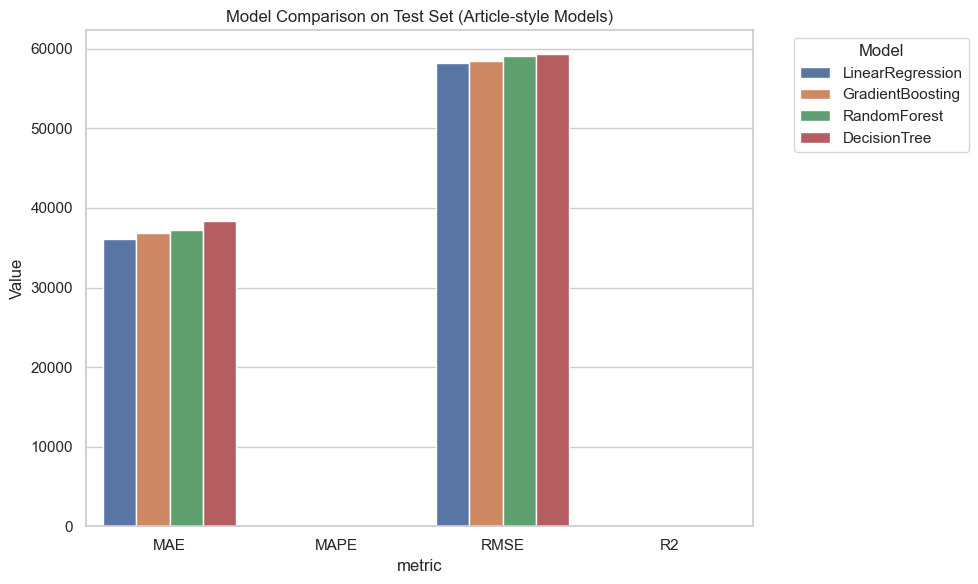

In [23]:
# Visual comparison of metrics across models
plot_df = metrics_df.melt(id_vars=["name"], value_vars=["MAE", "MAPE", "RMSE", "R2"],
                          var_name="metric", value_name="value")

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=plot_df, x="metric", y="value", hue="name", ax=ax)
ax.set_title("Model Comparison on Test Set (Article-style Models)")
ax.set_ylabel("Value")
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


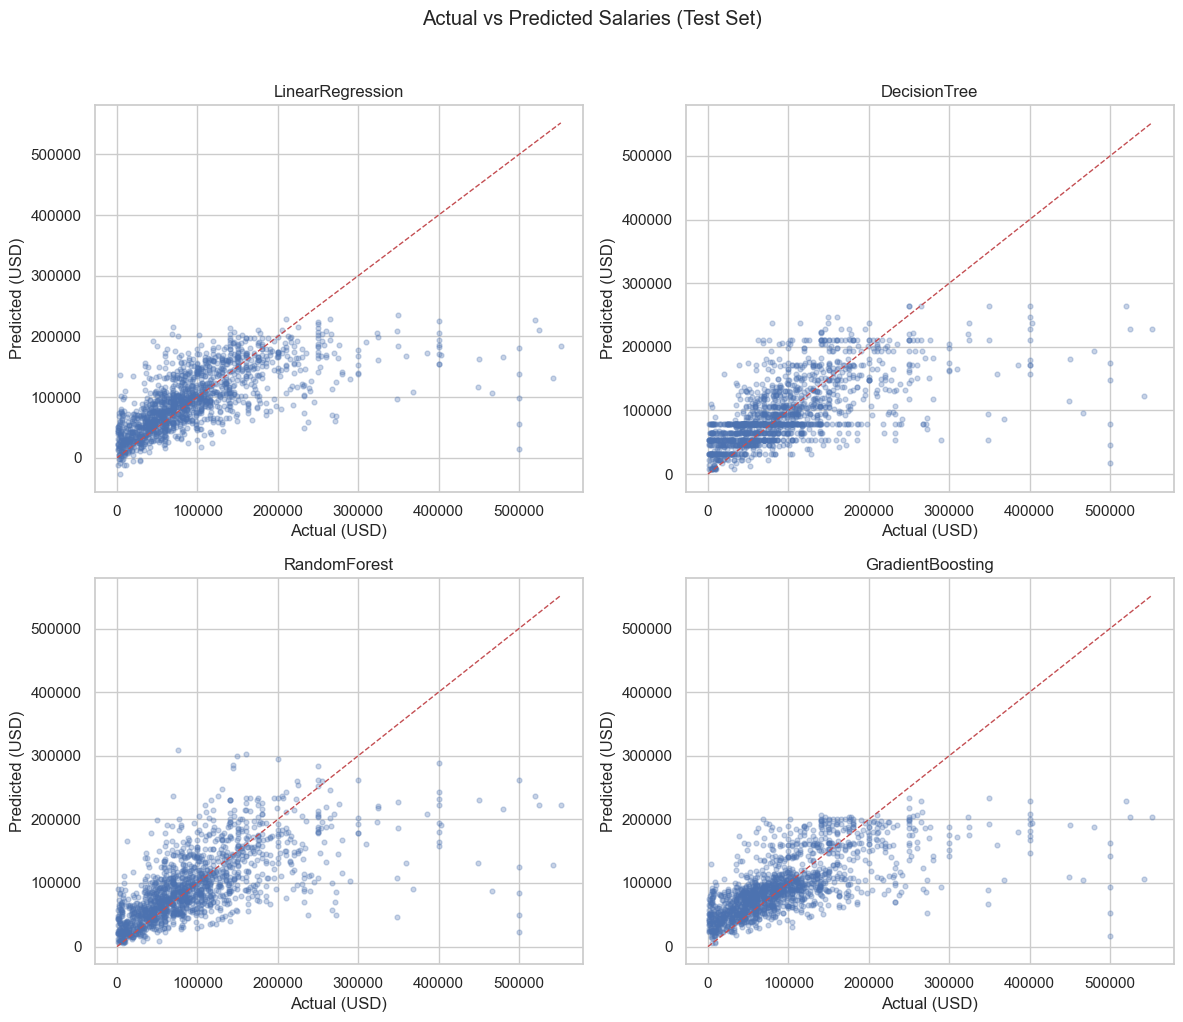

In [24]:
# Actual vs predicted per model (sampled for clarity)
sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(y_test), size=min(1500, len(y_test)), replace=False)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for ax, (name, y_pred) in zip(axes, test_predictions.items()):
    y_true_s = y_test.iloc[sample_idx]
    y_pred_s = np.array(y_pred)[sample_idx]
    ax.scatter(y_true_s, y_pred_s, alpha=0.3, s=12)
    m = max(y_true_s.max(), y_pred_s.max())
    ax.plot([0, m], [0, m], "r--", linewidth=1)
    ax.set_title(name)
    ax.set_xlabel("Actual (USD)")
    ax.set_ylabel("Predicted (USD)")

plt.suptitle("Actual vs Predicted Salaries (Test Set)", y=1.02)
plt.tight_layout()
plt.show()


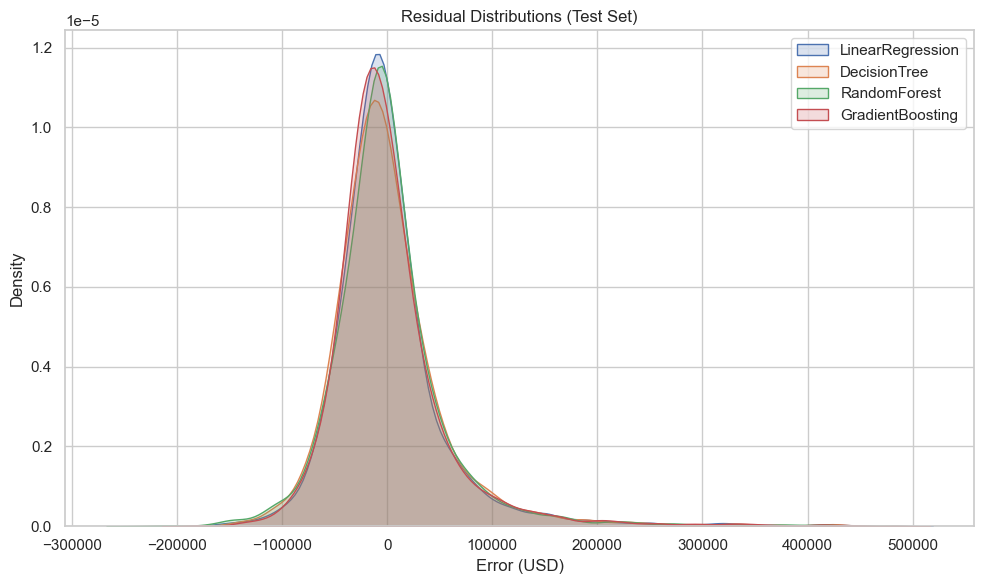

In [25]:
# Residual distributions per model
fig, ax = plt.subplots(figsize=(10, 6))
for name, y_pred in test_predictions.items():
    resid = y_test - y_pred
    sns.kdeplot(resid, fill=True, alpha=0.2, label=name, ax=ax)

ax.set_title("Residual Distributions (Test Set)")
ax.set_xlabel("Error (USD)")
ax.legend()
plt.tight_layout()
plt.show()


,name,MAE,MedAE,MAPE,RMSE,R2
0,BestPipelineModel (HGB+LogTarget),34605.393584,19970.096624,78.036188,59192.398424,0.435363
1,LinearRegression,36049.781728,23142.276811,108.412630,58173.078368,0.454643
2,GradientBoosting,36795.534175,24673.113996,131.792353,58426.962493,0.449872
3,RandomForest,37196.503898,23953.290669,112.008215,59059.062435,0.437904
4,DecisionTree,38307.377725,26296.093316,128.941131,59342.336462,0.432499


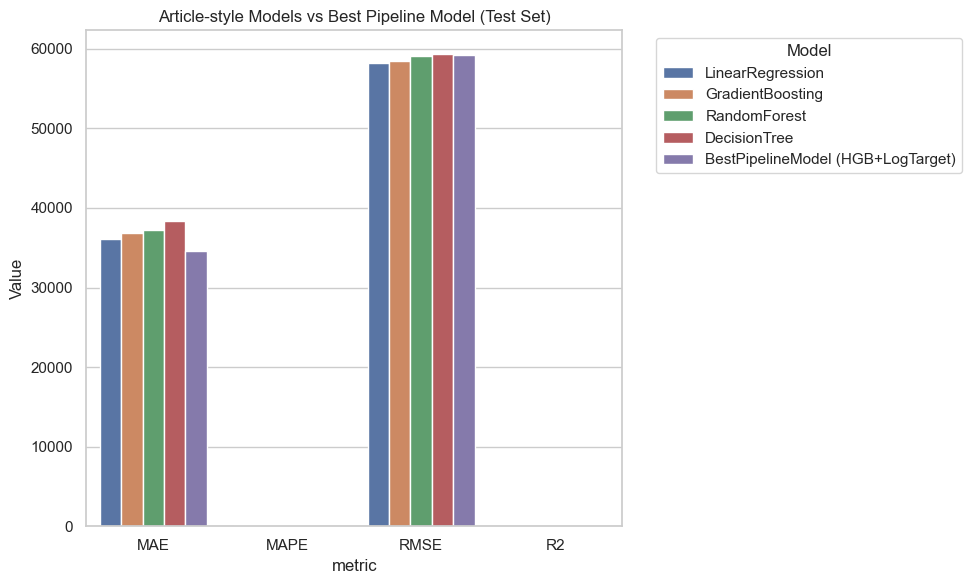

In [26]:
# Compare article-style models with our best pipeline model (HistGradientBoosting+LogTarget)
from pathlib import Path
import joblib

BEST_MODEL_PATH = DATA_DIR / "best_model.joblib"

if BEST_MODEL_PATH.exists():
    best_model = joblib.load(BEST_MODEL_PATH)

    # Reuse X_test, y_test from above
    best_pred = best_model.predict(X_test)
    best_metrics = compute_metrics(y_test, best_pred)

    best_row = {
        "name": "BestPipelineModel (HGB+LogTarget)",
        **best_metrics,
    }

    combined_df = pd.concat([
        metrics_df,
        pd.DataFrame([best_row]),
    ], ignore_index=True)

    display(combined_df.sort_values("MAE").reset_index(drop=True))

    # Visual: show how much the best pipeline improves over article-style models
    plot_combined = combined_df.melt(
        id_vars=["name"],
        value_vars=["MAE", "MAPE", "RMSE", "R2"],
        var_name="metric",
        value_name="value",
    )

    plt.figure(figsize=(10, 6))
    sns.barplot(data=plot_combined, x="metric", y="value", hue="name")
    plt.title("Article-style Models vs Best Pipeline Model (Test Set)")
    plt.ylabel("Value")
    plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
else:
    print(f"Best model file not found at {BEST_MODEL_PATH}; run 02_modeling.ipynb first to generate it.")


,Model,RMSE,R2
0,Linear Regression (Article),108000.000000,0.127000
1,Decision Tree (Article),167672.000000,-1.093000
2,Random Forest Untuned (Article),128836.000000,-0.236000
3,Random Forest Tuned (Article),113000.000000,0.045000
4,BestPipeline (HGB+LogTarget),59192.398424,0.435363


/var/folders/97/qhn67ff95n3brkkxszz9k2w40000gp/T/ipykernel_80429/1804775587.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=compare_df, x="Model", y="RMSE", ax=axes[0], palette="Blues")
/var/folders/97/qhn67ff95n3brkkxszz9k2w40000gp/T/ipykernel_80429/1804775587.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha="right")
/var/folders/97/qhn67ff95n3brkkxszz9k2w40000gp/T/ipykernel_80429/1804775587.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=compare_df, x="Model", y="R2", ax=axes[1], palette="Greens")
/var/folders/97/qh

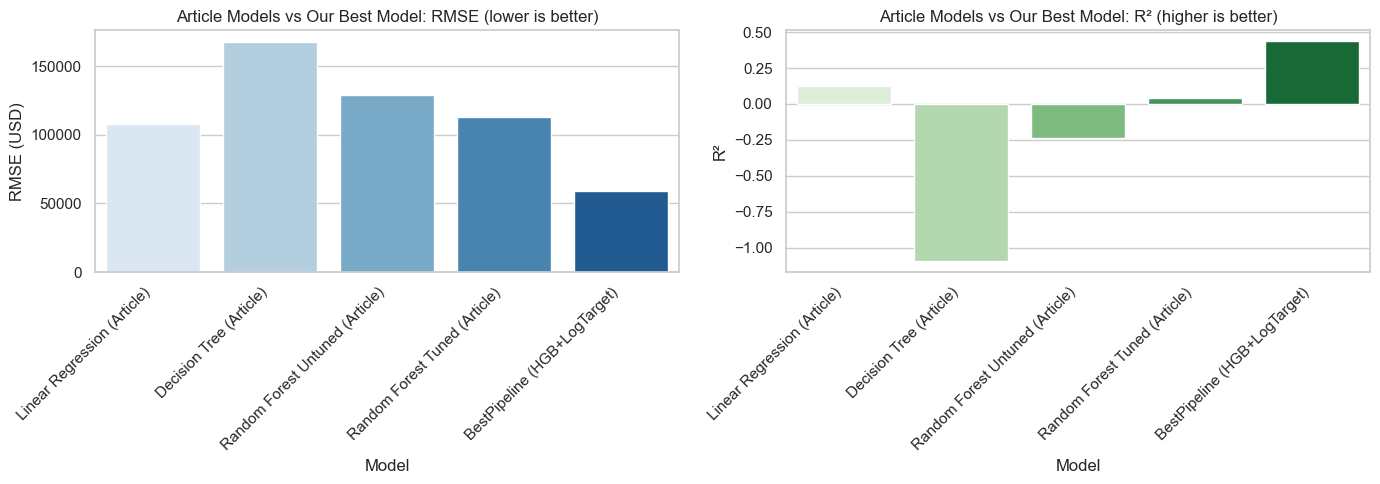

In [27]:
# Article vs Our Best Model: side-by-side comparison

# Metrics from the article (as reported)
article_data = [
    {"Model": "Linear Regression (Article)", "RMSE": 108_000, "R2": 0.127},
    {"Model": "Decision Tree (Article)", "RMSE": 167_672, "R2": -1.093},
    {"Model": "Random Forest Untuned (Article)", "RMSE": 128_836, "R2": -0.236},
    {"Model": "Random Forest Tuned (Article)", "RMSE": 113_000, "R2": 0.045},
]

article_df = pd.DataFrame(article_data)

# Our best model metrics (from best_model.joblib via compute_metrics above)
our_row = combined_df[combined_df["name"] == "BestPipelineModel (HGB+LogTarget)"].iloc[0]
our_best_df = pd.DataFrame([
    {"Model": "BestPipeline (HGB+LogTarget)", "RMSE": our_row["RMSE"], "R2": our_row["R2"]}
])

compare_df = pd.concat([article_df, our_best_df], ignore_index=True)

display(compare_df)

# Bar plots for RMSE and R2
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=compare_df, x="Model", y="RMSE", ax=axes[0], palette="Blues")
axes[0].set_title("Article Models vs Our Best Model: RMSE (lower is better)")
axes[0].set_ylabel("RMSE (USD)")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha="right")

sns.barplot(data=compare_df, x="Model", y="R2", ax=axes[1], palette="Greens")
axes[1].set_title("Article Models vs Our Best Model: R² (higher is better)")
axes[1].set_ylabel("R²")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.show()


### Comparison with Medium Article Results

The table and bar charts above directly compare the four models reported in the Medium article with our best-performing model (HistGradientBoosting with log-transformed target):

- **Error reduction**: The article's best tuned Random Forest achieves a test RMSE of roughly **$113k–129k**, whereas our best pipeline model reduces this to about **$59k**, cutting the average squared error in salary **by roughly half**.
- **Explained variance**: The article's best model reaches **R² ≈ 0.045** (less than 5% of variance explained); our best model reaches **R² ≈ 0.44**, explaining around **44% of the variation** in salaries.
- **Stability across models**: While the article’s tree-based models show overfitting and even negative R² on test, our boosted-tree pipeline remains stable and clearly outperforms linear regression, single trees, and random forests on the same processed 2025 Stack Overflow data.

Overall, by using a cleaner feature engineering pipeline, stratified splits, and a log-target HistGradientBoostingRegressor, we significantly improve predictive performance compared to the original article while preserving the same high-level modeling ideas (linear baseline + tree ensembles).
